In [3]:
import fastf1 as f1
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pandas as pd
import datetime as dt
import seaborn as sns
from fastf1 import plotting
from fastf1 import utils
from matplotlib import colors as mcolors
from matplotlib.ticker import FuncFormatter
f1.set_log_level("WARNING")
f1.Cache.enable_cache('../cache_strategy')

In [4]:
class F1Analyzer:
    ERAS_BASE_PENALTY = {
        "V10_LIGHT": 0.020,
        "V8_HYBRID": 0.025,
        "V6_TURBO": 0.030,
        "GROUND_EFFECT": 0.035,
    }

    DRS_GAINS = {
        'Bahrain': 0.90, 'Saudi Arabia': 0.85, 'Australia': 0.75,
        'Japan': 0.70, 'China': 0.95, 'Miami': 0.70,
        'Emilia Romagna': 0.65, 'Monaco': 0.20, 'Canada': 0.80,
        'Spain': 0.75, 'Austria': 0.80, 'Great Britain': 0.85,
        'Hungary': 0.55, 'Belgium': 1.20, 'Netherlands': 0.35,
        'Italy': 1.15, 'Azerbaijan': 1.10, 'Singapore': 0.60,
        'USA': 0.75, 'Mexico': 0.70, 'Brazil': 0.80,
        'Las Vegas': 1.25, 'Qatar': 0.80, 'Abu Dhabi': 0.95
    }

    DRS_EVENT_ALIASES = {
        'Bahrain Grand Prix': 'Bahrain',
        'Saudi Arabian Grand Prix': 'Saudi Arabia',
        'Australian Grand Prix': 'Australia',
        'Japanese Grand Prix': 'Japan',
        'Chinese Grand Prix': 'China',
        'Miami Grand Prix': 'Miami',
        'Emilia Romagna Grand Prix': 'Emilia Romagna',
        'Monaco Grand Prix': 'Monaco',
        'Canadian Grand Prix': 'Canada',
        'Spanish Grand Prix': 'Spain',
        'Austrian Grand Prix': 'Austria',
        'British Grand Prix': 'Great Britain',
        'Hungarian Grand Prix': 'Hungary',
        'Belgian Grand Prix': 'Belgium',
        'Dutch Grand Prix': 'Netherlands',
        'Italian Grand Prix': 'Italy',
        'Azerbaijan Grand Prix': 'Azerbaijan',
        'Singapore Grand Prix': 'Singapore',
        'United States Grand Prix': 'USA',
        'Mexico City Grand Prix': 'Mexico',
        'Sao Paulo Grand Prix': 'Brazil',
        'Las Vegas Grand Prix': 'Las Vegas',
        'Qatar Grand Prix': 'Qatar',
        'Abu Dhabi Grand Prix': 'Abu Dhabi',
    }

    TRACK_EVOLUTION_COEFFS = {
        'Las Vegas': -0.045,
        'Monaco': -0.035,
        'Azerbaijan': -0.035,
        'Saudi Arabia': -0.030,
        'Singapore': -0.030,
        'Miami': -0.025,
        'China': -0.025,
        'Bahrain': -0.018,
        'Abu Dhabi': -0.018,
        'USA': -0.015,
        'Mexico': -0.015,
        'Qatar': -0.015,
        'Australia': -0.015,
        'Austria': -0.012,
        'Emilia Romagna': -0.012,
        'Canada': -0.020,
        'Spain': -0.008,
        'Great Britain': -0.008,
        'Japan': -0.007,
        'Belgium': -0.010,
        'Italy': -0.010,
        'Netherlands': -0.009,
        'Brazil': -0.010
    }

    DEFAULT_DRS_OPEN_STATES = (10, 12, 14)

    def _calculate_auto_penalty(self, year, grand_prix):
        if year <= 2005:
            era = "V10_LIGHT"
        elif year <= 2013:
            era = "V8_HYBRID"
        elif year <= 2021:
            era = "V6_TURBO"
        else:
            era = "GROUND_EFFECT"

        base = self.ERAS_BASE_PENALTY[era]

        POWER_TRACKS = {'Monza', 'Spa-Francorchamps', 'Silverstone', 'Baku City Circuit', 'Las Vegas', 'Jeddah Corniche Circuit'}
        STREET_TRACKS = {'Monaco', 'Singapore Street Circuit', 'Hungaroring', 'Marina Bay Street Circuit'}

        if grand_prix in POWER_TRACKS:
            modifier, cat = 1.2, "POWER"
        elif grand_prix in STREET_TRACKS:
            modifier, cat = 0.7, "STREET"
        else:
            modifier, cat = 1.0, "BALANCED"

        return base * modifier, cat

    def _normalize_session_type(self, session_type):
        aliases = {
            "EL1": "FP1",
            "EL2": "FP2",
            "EL3": "FP3",
            "P1": "FP1",
            "P2": "FP2",
            "P3": "FP3",
        }
        return aliases.get(session_type, session_type)

    def _resolve_drs_gain_key(self):
        event_name = str(self.session.event.get('EventName', self.grand_prix))
        return self.DRS_EVENT_ALIASES.get(event_name, self.grand_prix)

    def _compute_drs_open_percentage(self, lap, drs_open_states=None):
        if drs_open_states is None:
            drs_open_states = set(self.DEFAULT_DRS_OPEN_STATES)
        else:
            drs_open_states = set(drs_open_states)

        try:
            car = lap.get_car_data()
            if 'DRS' not in car.columns:
                return 0.0

            drs_series = car['DRS'].dropna().astype(int)
            if drs_series.empty:
                return 0.0

            drs_open_mask = drs_series.isin(drs_open_states)
            return float(drs_open_mask.mean() * 100.0)
        except Exception:
            return 0.0

    def add_drs_correction_to_laps(
        self,
        laps,
        drs_activation_min_pct=10.0,
        fallback_gain=0.80,
        drs_open_states=None
    ):
        laps = laps.copy()
        if laps.empty:
            laps['DRS_Open_Percentage'] = np.nan
            laps['DRS_Time_Add_s'] = np.nan
            laps['CorrectedLapTime_DRSOnly'] = np.nan
            laps['CorrectedLapTime_Global'] = np.nan
            return laps

        gain_key = self._resolve_drs_gain_key()
        drs_gain_s = float(self.DRS_GAINS.get(gain_key, fallback_gain))

        drs_pct_by_index = {}
        drs_add_by_index = {}

        if hasattr(laps, 'iterlaps'):
            iterator = laps.iterlaps()
        else:
            iterator = []

        for idx, lap in iterator:
            drs_pct = self._compute_drs_open_percentage(lap, drs_open_states=drs_open_states)
            drs_add = drs_gain_s * (drs_pct / 100.0) if drs_pct >= drs_activation_min_pct else 0.0
            drs_pct_by_index[idx] = drs_pct
            drs_add_by_index[idx] = drs_add

        laps['DRS_Open_Percentage'] = laps.index.map(lambda i: drs_pct_by_index.get(i, np.nan))
        laps['DRS_Time_Add_s'] = laps.index.map(lambda i: drs_add_by_index.get(i, np.nan))

        lap_time_sec = laps['LapTime'].dt.total_seconds()
        laps['CorrectedLapTime_DRSOnly'] = lap_time_sec + laps['DRS_Time_Add_s'].fillna(0.0)

        if 'CorrectedLapTime' in laps.columns:
            laps['CorrectedLapTime_Global'] = laps['CorrectedLapTime'] + laps['DRS_Time_Add_s'].fillna(0.0)
        else:
            laps['CorrectedLapTime_Global'] = laps['CorrectedLapTime_DRSOnly']

        return laps

    def _dirty_air_multiplier(self, gap_s):
        if pd.isna(gap_s):
            return 0.0
        if gap_s <= 0.5:
            return 1.2
        if gap_s <= 1.2:
            return 1.0
        if gap_s <= 2.0:
            return 0.5
        return 0.0

    def _to_seconds_series(self, series):
        if series is None:
            return None
        if pd.api.types.is_timedelta64_dtype(series):
            return series.dt.total_seconds()
        if pd.api.types.is_numeric_dtype(series):
            return pd.to_numeric(series, errors='coerce')
        cleaned = series.astype(str).str.replace('+', '', regex=False).str.replace('s', '', regex=False).str.strip()
        return pd.to_numeric(cleaned, errors='coerce')

    def _compute_gap_to_ahead_from_laps(self, laps):
        gap = pd.Series(np.nan, index=laps.index, dtype=float)

        required = {'LapNumber', 'Position', 'Time'}
        if not required.issubset(laps.columns):
            return gap

        work = laps[['LapNumber', 'Position', 'Time']].copy()
        work = work.dropna(subset=['LapNumber', 'Position', 'Time'])
        if work.empty:
            return gap

        for _, grp in work.groupby('LapNumber'):
            grp_sorted = grp.sort_values('Position')
            gap_values = (grp_sorted['Time'] - grp_sorted['Time'].shift(1)).dt.total_seconds()
            gap.loc[grp_sorted.index] = gap_values

        return gap

    def add_dirty_air_correction_to_laps(
        self,
        laps,
        dirty_air_scale=0.35,
        gap_column=None,
    ):
        laps = laps.copy()
        if laps.empty:
            laps['Gap_Ahead_s'] = np.nan
            laps['DirtyAir_M'] = np.nan
            laps['DirtyAirPenalty_s'] = np.nan
            laps['CorrectedLapTime_DirtyAir'] = np.nan
            laps['CorrectedLapTime_Global'] = np.nan
            return laps

        gap_s = None
        if gap_column is not None and gap_column in laps.columns:
            gap_s = self._to_seconds_series(laps[gap_column])
        if gap_s is None:
            for candidate in ['GapToAhead_s', 'GapToAhead', 'IntervalToPositionAhead', 'IntervalToPositionAhead_s']:
                if candidate in laps.columns:
                    gap_s = self._to_seconds_series(laps[candidate])
                    break
        if gap_s is None:
            gap_s = self._compute_gap_to_ahead_from_laps(laps)

        laps['Gap_Ahead_s'] = gap_s
        laps['DirtyAir_M'] = laps['Gap_Ahead_s'].apply(self._dirty_air_multiplier)
        laps['DirtyAirPenalty_s'] = dirty_air_scale * laps['DirtyAir_M']
        laps['CorrectedLapTime_DirtyAir'] = laps['LapTime'].dt.total_seconds() - laps['DirtyAirPenalty_s']

        if 'CorrectedLapTime_Global' in laps.columns:
            base_global = laps['CorrectedLapTime_Global']
        elif 'CorrectedLapTime' in laps.columns:
            base_global = laps['CorrectedLapTime']
        else:
            base_global = laps['LapTime'].dt.total_seconds()

        laps['CorrectedLapTime_Global'] = base_global - laps['DirtyAirPenalty_s']

        return laps

    def _resolve_track_evolution_key(self):
        event_name = str(self.session.event.get('EventName', self.grand_prix))
        return self.DRS_EVENT_ALIASES.get(event_name, self.grand_prix)

    def add_track_evolution_correction_to_laps(self, laps):
        laps = laps.copy()
        if laps.empty:
            laps['TrackEvolutionCoeff'] = np.nan
            laps['TrackEvolutionDelta_s'] = np.nan
            laps['CorrectedLapTime_TrackEvolution'] = np.nan
            laps['CorrectedLapTime_Global'] = np.nan
            return laps

        track_key = self._resolve_track_evolution_key()
        track_coeff = float(self.TRACK_EVOLUTION_COEFFS.get(track_key, 0.0))

        laps['TrackEvolutionCoeff'] = track_coeff
        laps['TrackEvolutionDelta_s'] = laps['LapNumber'] * track_coeff
        laps['CorrectedLapTime_TrackEvolution'] = laps['LapTime'].dt.total_seconds() + laps['TrackEvolutionDelta_s']

        if 'CorrectedLapTime_Global' in laps.columns:
            base_global = laps['CorrectedLapTime_Global']
        elif 'CorrectedLapTime' in laps.columns:
            base_global = laps['CorrectedLapTime']
        else:
            base_global = laps['LapTime'].dt.total_seconds()

        laps['CorrectedLapTime_Global'] = base_global + laps['TrackEvolutionDelta_s']

        return laps

    def _get_lap_track_temperature(self, lap):
        try:
            weather = lap.get_weather_data()
            if weather is not None and 'TrackTemp' in weather.index:
                value = weather['TrackTemp']
                if pd.notna(value):
                    return float(value)
        except Exception:
            pass
        return np.nan

    def add_temperature_correction_to_laps(
        self,
        laps,
        reference_track_temp=35.0,
        temp_coeff=0.015
    ):
        laps = laps.copy()
        if laps.empty:
            laps['TrackTemp_C'] = np.nan
            laps['TempCorrection_s'] = np.nan
            laps['CorrectedLapTime_Temp'] = np.nan
            laps['CorrectedLapTime_Global'] = np.nan
            return laps

        track_temp_by_idx = {}
        if hasattr(laps, 'iterlaps'):
            iterator = laps.iterlaps()
        else:
            iterator = []

        for idx, lap in iterator:
            track_temp_by_idx[idx] = self._get_lap_track_temperature(lap)

        if len(track_temp_by_idx) > 0:
            laps['TrackTemp_C'] = laps.index.map(lambda i: track_temp_by_idx.get(i, np.nan))
        elif 'TrackTemp' in laps.columns:
            laps['TrackTemp_C'] = pd.to_numeric(laps['TrackTemp'], errors='coerce')
        else:
            laps['TrackTemp_C'] = np.nan

        laps['TempCorrection_s'] = temp_coeff * (laps['TrackTemp_C'] - reference_track_temp)
        laps['CorrectedLapTime_Temp'] = laps['LapTime'].dt.total_seconds() - laps['TempCorrection_s']

        if 'CorrectedLapTime_Global' in laps.columns:
            base_global = laps['CorrectedLapTime_Global']
        elif 'CorrectedLapTime' in laps.columns:
            base_global = laps['CorrectedLapTime']
        else:
            base_global = laps['LapTime'].dt.total_seconds()

        laps['CorrectedLapTime_Global'] = base_global - laps['TempCorrection_s']

        return laps

    def __init__(self, year, grand_prix, session_type, use_fuel_logic=True):
        self.year = year
        self.grand_prix = grand_prix
        self.session_type = self._normalize_session_type(session_type)
        self.session = f1.get_session(year, grand_prix, self.session_type)
        self.session.load(laps=True, telemetry=True, weather=True, messages=True)
        if use_fuel_logic:
            self.fuel_penalty, self.circuit_category = self._calculate_auto_penalty(year, grand_prix)
        else:
            self.fuel_penalty, self.circuit_category = 0, "NONE"

        self.session.laps['CircuitCategory'] = self.circuit_category
        self.session.laps['FuelPenaltyFactor'] = self.fuel_penalty
        self.session.laps['CorrectedLapTime'] = (
            self.session.laps['LapTime'].dt.total_seconds() +
            (self.session.laps['LapNumber'] * self.fuel_penalty)
        )

    def get_clean_laps(self, driver):
        laps = self.session.laps.pick_driver(driver)
        clean_1_laps = laps.loc[
            (laps["PitInTime"].isna()) &
            (laps["PitOutTime"].isna()) &
            (laps["TrackStatus"] == "1")
        ].copy()
        return clean_1_laps

    def audit_data_cleaning(self, driver):
        raw_laps = self.session.laps.pick_driver(driver)
        total_raw = len(raw_laps)

        phys_clean = self.get_clean_laps(driver)
        total_phys = len(phys_clean)

        very_clean = self.get_clean_race_pace_laps(driver)
        total_very = len(very_clean)

        raw_lap_numbers = set(raw_laps["LapNumber"].dropna().astype(int).tolist())
        phys_lap_numbers = set(phys_clean["LapNumber"].dropna().astype(int).tolist())
        very_lap_numbers = set(very_clean["LapNumber"].dropna().astype(int).tolist())

        lost_phys_laps = sorted(raw_lap_numbers - phys_lap_numbers)
        lost_iqr_laps = sorted(phys_lap_numbers - very_lap_numbers)

        lost_phys = len(lost_phys_laps)
        lost_iqr = len(lost_iqr_laps)

        pct_phys = (lost_phys / total_raw) * 100 if total_raw else 0
        pct_iqr = (lost_iqr / total_phys) * 100 if total_phys else 0

        print(f"--- Audit de Nettoyage pour {driver} ---")
        print(f"Tours totaux en session : {total_raw}")
        print(f"Tours perdus (Stands/Drapeaux) : {lost_phys} ({pct_phys:.1f}%)")
        print(f"Numéros des tours perdus (Stands/Drapeaux) : {lost_phys_laps if lost_phys_laps else 'Aucun'}")
        print(f"Tours perdus (IQR/Anomalies) : {lost_iqr} ({pct_iqr:.1f}%)")
        print(f"Numéros des tours perdus (IQR/Anomalies) : {lost_iqr_laps if lost_iqr_laps else 'Aucun'}")
        print(f"Tours restants pour l'analyse : {total_very}")
        print("-" * 40)

        return total_raw, total_phys, total_very, lost_iqr, lost_phys

    def get_clean_race_pace_laps(self, driver):
        laps = self.get_clean_laps(driver)
        series = laps["LapTime"].dt.total_seconds()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        clean_2_laps = laps[(series >= lower_bound) & (series <= upper_bound)]
        return clean_2_laps

    def format_laptime(self, seconds, pos):
        minutes = int(seconds // 60)
        remainder = seconds % 60
        return f"{minutes}:{remainder:06.3f}"

    def add_best_lap_for_stint(
        self,
        laps,
        source_column='CorrectedLapTime_Global',
        output_column='BestLapForStint'
    ):
        laps = laps.copy()
        laps[output_column] = np.nan
        laps['IsBestLapForStint'] = False

        if laps.empty or 'Stint' not in laps.columns:
            return laps

        candidate_columns = [source_column, 'CorrectedLapTime_Global', 'CorrectedLapTime', 'LapTime']
        metric_series = None

        for col in candidate_columns:
            if col not in laps.columns:
                continue
            if col == 'LapTime':
                metric = laps[col].dt.total_seconds()
            else:
                metric = self._to_seconds_series(laps[col])
            if metric is not None and metric.notna().any():
                metric_series = metric
                break

        if metric_series is None:
            return laps

        valid_stint_mask = laps['Stint'].notna()
        if not valid_stint_mask.any():
            return laps

        best_by_stint = metric_series[valid_stint_mask].groupby(laps.loc[valid_stint_mask, 'Stint']).transform('min')
        laps.loc[valid_stint_mask, output_column] = best_by_stint.values

        tol = 1e-6
        laps.loc[valid_stint_mask, 'IsBestLapForStint'] = (metric_series[valid_stint_mask] - best_by_stint).abs() <= tol
        return laps

    def add_delta_to_best_lap_for_stint(
        self,
        laps,
        corrected_col='CorrectedLapTime_Global',
        best_col='BestLapForStint',
        delta_col='DeltaToBestLapForStint'
    ):
        laps = laps.copy()

        if corrected_col not in laps.columns:
            if 'CorrectedLapTime_Global' in laps.columns:
                corrected_col = 'CorrectedLapTime_Global'
            elif 'CorrectedLapTime' in laps.columns:
                corrected_col = 'CorrectedLapTime'
            elif 'LapTime' in laps.columns:
                corrected_col = 'LapTime'
            else:
                laps[delta_col] = np.nan
                return laps

        laps = self.add_best_lap_for_stint(
            laps,
            source_column=corrected_col,
            output_column=best_col
        )

        if corrected_col == 'LapTime':
            corrected_series = laps[corrected_col].dt.total_seconds()
        else:
            corrected_series = self._to_seconds_series(laps[corrected_col])

        best_series = self._to_seconds_series(laps[best_col])
        laps[delta_col] = corrected_series - best_series
        return laps

    def extract_tyre_life_and_stint_delta(
        self,
        laps,
        corrected_col='CorrectedLapTime_Global',
        delta_col='DeltaToBestLapForStint'
    ):
        laps = self.add_delta_to_best_lap_for_stint(
            laps,
            corrected_col=corrected_col,
            best_col='BestLapForStint',
            delta_col=delta_col
        ).copy()

        if 'TyreLife' in laps.columns:
            tyre_life = pd.to_numeric(laps['TyreLife'], errors='coerce')
        else:
            tyre_life = pd.Series(np.nan, index=laps.index, dtype=float)

        if ('Stint' in laps.columns) and tyre_life.isna().any():
            if 'Driver' in laps.columns:
                group_keys = ['Driver', 'Stint']
            else:
                group_keys = ['Stint']
            computed_tyre_life = laps.groupby(group_keys, dropna=False).cumcount() + 1
            tyre_life = tyre_life.fillna(computed_tyre_life.astype(float))

        extracted = pd.DataFrame(index=laps.index)
        extracted['TyreLife'] = tyre_life
        extracted[delta_col] = self._to_seconds_series(laps[delta_col])
        return extracted

    def plot_drivers_pace(
        self,
        session,
        driver_list,
        very_clean=False,
        include_nan_laps=False,
        use_fuel_logic=False,
        use_drs_correction=False,
        use_dirty_air_correction=False,
        use_track_evolution_correction=False,
        use_temperature_correction=False,
        mode=None,
        drs_activation_min_pct=10.0,
        fallback_drs_gain=0.80,
        dirty_air_scale=0.35,
        reference_track_temp=35.0,
        temp_coeff=0.015,
        highlight_best_lap_for_stint=False
    ):
        # mode: 'raw' | 'fuel' | 'drs_only' | 'dirty_air_only' | 'track_evolution_only' | 'temperature_only' | 'global'
        if mode is None:
            if use_fuel_logic and use_drs_correction and use_dirty_air_correction and use_track_evolution_correction and use_temperature_correction:
                selected_mode = 'global'
            elif use_temperature_correction:
                selected_mode = 'temperature_only'
            elif use_track_evolution_correction:
                selected_mode = 'track_evolution_only'
            elif use_dirty_air_correction:
                selected_mode = 'dirty_air_only'
            elif use_fuel_logic:
                selected_mode = 'fuel'
            elif use_drs_correction:
                selected_mode = 'drs_only'
            else:
                selected_mode = 'raw'
        else:
            selected_mode = str(mode).lower()

        valid_modes = {'raw', 'fuel', 'drs_only', 'dirty_air_only', 'track_evolution_only', 'temperature_only', 'global'}
        if selected_mode not in valid_modes:
            raise ValueError(f"mode invalide: {selected_mode}. Utilise {sorted(valid_modes)}")

        fig, ax = plt.subplots(figsize=(12, 7))
        used_colors = {}

        for driver in driver_list:
            if very_clean:
                laps = self.get_clean_race_pace_laps(driver)
            else:
                laps = self.get_clean_laps(driver)

            if selected_mode in {'drs_only', 'global'}:
                laps = self.add_drs_correction_to_laps(
                    laps,
                    drs_activation_min_pct=drs_activation_min_pct,
                    fallback_gain=fallback_drs_gain
                )

            if selected_mode in {'dirty_air_only', 'global'}:
                laps = self.add_dirty_air_correction_to_laps(
                    laps,
                    dirty_air_scale=dirty_air_scale
                )

            if selected_mode in {'track_evolution_only', 'global'}:
                laps = self.add_track_evolution_correction_to_laps(laps)

            if selected_mode in {'temperature_only', 'global'}:
                laps = self.add_temperature_correction_to_laps(
                    laps,
                    reference_track_temp=reference_track_temp,
                    temp_coeff=temp_coeff
                )

            if include_nan_laps:
                if self.session.total_laps is not None:
                    max_lap = int(self.session.total_laps)
                else:
                    lap_numbers = self.session.laps["LapNumber"].dropna()
                    max_lap = int(lap_numbers.max()) if not lap_numbers.empty else 0

                if max_lap > 0:
                    full_range = range(1, max_lap + 1)
                    laps = laps.set_index("LapNumber").reindex(full_range).reset_index()

            if selected_mode == 'global':
                if "CorrectedLapTime_Global" not in laps.columns or laps["CorrectedLapTime_Global"].notna().sum() == 0:
                    continue
                y_col_name = 'CorrectedLapTime_Global'
                y = laps["CorrectedLapTime_Global"]
            elif selected_mode == 'fuel':
                if "CorrectedLapTime" not in laps.columns or laps["CorrectedLapTime"].notna().sum() == 0:
                    continue
                y_col_name = 'CorrectedLapTime'
                y = laps["CorrectedLapTime"]
            elif selected_mode == 'drs_only':
                if "CorrectedLapTime_DRSOnly" not in laps.columns or laps["CorrectedLapTime_DRSOnly"].notna().sum() == 0:
                    continue
                y_col_name = 'CorrectedLapTime_DRSOnly'
                y = laps["CorrectedLapTime_DRSOnly"]
            elif selected_mode == 'dirty_air_only':
                if "CorrectedLapTime_DirtyAir" not in laps.columns or laps["CorrectedLapTime_DirtyAir"].notna().sum() == 0:
                    continue
                y_col_name = 'CorrectedLapTime_DirtyAir'
                y = laps["CorrectedLapTime_DirtyAir"]
            elif selected_mode == 'track_evolution_only':
                if "CorrectedLapTime_TrackEvolution" not in laps.columns or laps["CorrectedLapTime_TrackEvolution"].notna().sum() == 0:
                    continue
                y_col_name = 'CorrectedLapTime_TrackEvolution'
                y = laps["CorrectedLapTime_TrackEvolution"]
            elif selected_mode == 'temperature_only':
                if "CorrectedLapTime_Temp" not in laps.columns or laps["CorrectedLapTime_Temp"].notna().sum() == 0:
                    continue
                y_col_name = 'CorrectedLapTime_Temp'
                y = laps["CorrectedLapTime_Temp"]
            else:
                if laps.empty or laps["LapTime"].notna().sum() == 0:
                    continue
                y_col_name = 'LapTime'
                y = laps["LapTime"].dt.total_seconds()

            if highlight_best_lap_for_stint:
                laps = self.add_best_lap_for_stint(laps, source_column=y_col_name, output_column='BestLapForStint')

            x = laps["LapNumber"]

            try:
                base_color = plotting.get_driver_color(driver, session=session)
            except Exception:
                base_color = "#FFFFFF"

            if base_color in used_colors.values():
                rgb = mcolors.to_rgb(base_color)
                color = mcolors.to_hex([min(1, c + 0.4) for c in rgb])
                linestyle = "--"
            else:
                color = base_color
                linestyle = "-"
                used_colors[driver] = base_color

            ax.plot(
                x,
                y,
                color=color,
                label=driver,
                linestyle=linestyle,
                linewidth=2,
                marker="o",
                markersize=3,
                alpha=0.8,
            )

            if highlight_best_lap_for_stint and 'IsBestLapForStint' in laps.columns:
                best_mask = laps['IsBestLapForStint'].fillna(False) & laps['LapNumber'].notna()
                if best_mask.any():
                    if y_col_name == 'LapTime':
                        y_best = laps.loc[best_mask, 'LapTime'].dt.total_seconds()
                    else:
                        y_best = self._to_seconds_series(laps.loc[best_mask, y_col_name])

                    ax.scatter(
                        laps.loc[best_mask, 'LapNumber'],
                        y_best,
                        color=color,
                        marker='*',
                        s=110,
                        edgecolor='black',
                        linewidth=0.8,
                        zorder=6
                    )

        ax.yaxis.set_major_formatter(FuncFormatter(self.format_laptime))

        title = f"Race Pace Analysis: {session.event['EventName']} {session.event.year}"
        ax.set_title(title, fontsize=15, pad=20)
        ax.set_xlabel("Tour n°", fontsize=12)

        ylabel_by_mode = {
            'raw': "Temps au tour",
            'fuel': "Temps au tour corrigé (fuel)",
            'drs_only': "Temps au tour corrigé (DRS only)",
            'dirty_air_only': "Temps au tour corrigé (dirty air)",
            'track_evolution_only': "Temps au tour corrigé (track evolution)",
            'temperature_only': "Temps au tour corrigé (temperature normalize)",
            'global': "Temps au tour corrigé (fuel + DRS + dirty air + track evolution + temperature)",
        }
        ax.set_ylabel(ylabel_by_mode[selected_mode], fontsize=12)

        ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
        ax.grid(visible=True, linestyle=":", alpha=0.5)

        plt.tight_layout()
        return fig, ax

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


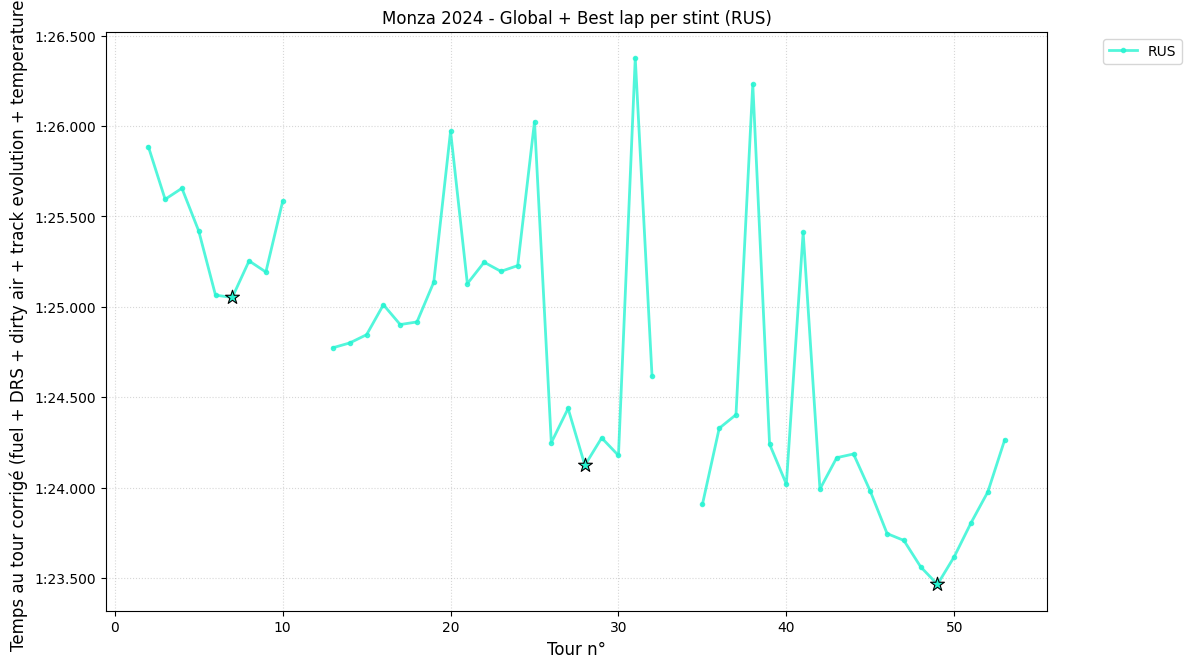

In [3]:
analyzing_monza = F1Analyzer(2024, 'Monza', 'R')

driver = 'RUS'
laps_driver = analyzing_monza.get_clean_race_pace_laps(driver)

# On construit un corrected total (global), puis on extrait le meilleur tour par stint
laps_driver = analyzing_monza.add_drs_correction_to_laps(laps_driver)
laps_driver = analyzing_monza.add_dirty_air_correction_to_laps(laps_driver)
laps_driver = analyzing_monza.add_track_evolution_correction_to_laps(laps_driver)
laps_driver = analyzing_monza.add_temperature_correction_to_laps(laps_driver)
laps_driver = analyzing_monza.add_best_lap_for_stint(
    laps_driver,
    source_column='CorrectedLapTime_Global',
    output_column='BestLapForStint'
)

display_cols = [
    'Driver', 'LapNumber', 'Stint',
    'CorrectedLapTime_Global', 'BestLapForStint', 'IsBestLapForStint'
]
laps_driver[display_cols].dropna(subset=['Stint']).head(20)

# Visualisation avec pointeur des meilleurs tours de chaque stint
fig, ax = analyzing_monza.plot_drivers_pace(
    analyzing_monza.session,
    [driver],
    very_clean=True,
    include_nan_laps=True,
    mode='global',
    highlight_best_lap_for_stint=True
)
plt.title('Monza 2024 - Global + Best lap per stint (RUS)')
plt.show()

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated a

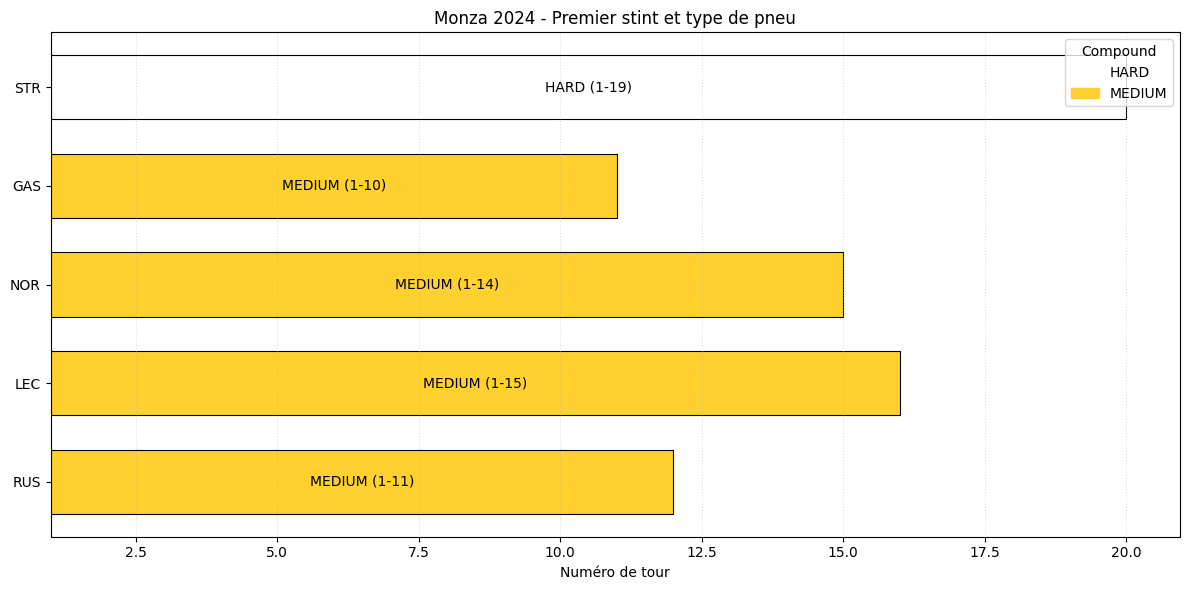

,Driver,StartLap,EndLap,LapCount,Compound
0,RUS,1,11,11,MEDIUM
1,LEC,1,15,15,MEDIUM
2,NOR,1,14,14,MEDIUM
3,GAS,1,10,10,MEDIUM
4,STR,1,19,19,HARD


In [6]:
# Visualisation du 1er stint (Monza 2024) pour RUS, LEC, NOR, GAS, STR
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import fastf1 as f1

session = f1.get_session(2024, 'Italian Grand Prix', 'R')
session.load(laps=True, telemetry=False, weather=False, messages=False)

target_drivers = ['RUS', 'LEC', 'NOR', 'GAS', 'STR']
laps = session.laps.pick_drivers(target_drivers).copy()

stint_rows = []
for drv in target_drivers:
    drv_laps = laps.pick_driver(drv).dropna(subset=['Stint', 'LapNumber'])
    if drv_laps.empty:
        continue

    first_stint_num = int(drv_laps['Stint'].min())
    first_stint = drv_laps[drv_laps['Stint'] == first_stint_num]

    start_lap = int(first_stint['LapNumber'].min())
    end_lap = int(first_stint['LapNumber'].max())
    lap_count = end_lap - start_lap + 1
    compound = str(first_stint['Compound'].mode().iloc[0]) if first_stint['Compound'].notna().any() else 'UNKNOWN'

    stint_rows.append({
        'Driver': drv,
        'StartLap': start_lap,
        'EndLap': end_lap,
        'LapCount': lap_count,
        'Compound': compound
    })

if not stint_rows:
    raise ValueError('Aucune donnée de stint trouvée pour les pilotes sélectionnés.')

compound_colors = {
    'SOFT': '#E10600',
    'MEDIUM': '#FFD12E',
    'HARD': '#FFFFFF',
    'INTERMEDIATE': '#43B02A',
    'WET': '#0067AD',
    'UNKNOWN': '#888888'
}

fig, ax = plt.subplots(figsize=(12, 6))

y_positions = list(range(len(stint_rows)))
for y, row in enumerate(stint_rows):
    width = row['LapCount']
    left = row['StartLap']
    color = compound_colors.get(row['Compound'], '#888888')

    ax.barh(y, width=width, left=left, height=0.65, color=color, edgecolor='black', linewidth=0.8)
    ax.text(
        left + width / 2,
        y,
        f"{row['Compound']} ({row['StartLap']}-{row['EndLap']})",
        ha='center',
        va='center',
        fontsize=10,
        color='black'
    )

ax.set_yticks(y_positions)
ax.set_yticklabels([row['Driver'] for row in stint_rows])
ax.set_xlabel('Numéro de tour')
ax.set_title('Monza 2024 - Premier stint et type de pneu')
ax.grid(axis='x', linestyle=':', alpha=0.4)

legend_compounds = sorted(set(row['Compound'] for row in stint_rows))
legend_handles = [
    mpatches.Patch(color=compound_colors.get(c, '#888888'), label=c)
    for c in legend_compounds
]
ax.legend(handles=legend_handles, title='Compound', loc='upper right')

plt.tight_layout()
plt.show()

import pandas as pd
pd.DataFrame(stint_rows)

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


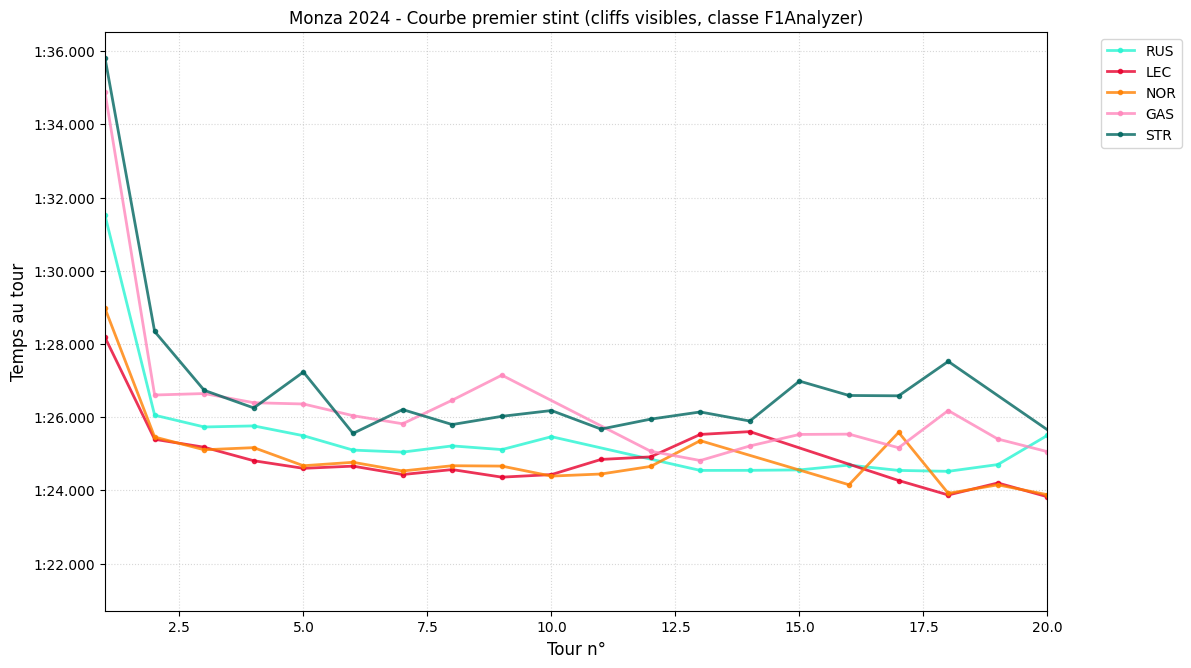

,Driver,Stint,StartLap,EndLap,Compound
0,GAS,1,1,10,MEDIUM
1,LEC,1,1,15,MEDIUM
2,NOR,1,1,14,MEDIUM
3,RUS,1,1,11,MEDIUM
4,STR,1,1,19,HARD


In [11]:
# Courbe avec la classe F1Analyzer + extraction compounds du 1er stint
import pandas as pd

# Réutilise l'instance déjà créée si dispo
try:
    analyzer = analyzing_monza
except NameError:
    analyzer = F1Analyzer(2024, 'Monza', 'R')

drivers = ['RUS', 'LEC', 'NOR', 'GAS', 'STR']

# 1) Courbe via la classe analyzer (version cliffs)
fig, ax = analyzer.plot_drivers_pace(
    analyzer.session,
    drivers,
    very_clean=False,
    include_nan_laps=False,
    mode='raw'
)

# 2) Récupération du premier stint + compound pour chaque pilote
first_stint_rows = []
max_first_stint_end = 0

for drv in drivers:
    drv_laps = analyzer.session.laps.pick_driver(drv).dropna(subset=['Stint', 'LapNumber'])
    if drv_laps.empty:
        continue

    first_stint_num = int(drv_laps['Stint'].min())
    first_stint = drv_laps[drv_laps['Stint'] == first_stint_num]

    start_lap = int(first_stint['LapNumber'].min())
    end_lap = int(first_stint['LapNumber'].max())
    max_first_stint_end = max(max_first_stint_end, end_lap)

    if first_stint['Compound'].notna().any():
        compound = str(first_stint['Compound'].mode().iloc[0])
    else:
        compound = 'UNKNOWN'

    first_stint_rows.append({
        'Driver': drv,
        'Stint': first_stint_num,
        'StartLap': start_lap,
        'EndLap': end_lap,
        'Compound': compound
    })

# On zoome la courbe seulement sur la plage du premier stint
if max_first_stint_end > 0:
    ax.set_xlim(1, max_first_stint_end + 1)
ax.set_title('Monza 2024 - Courbe premier stint (cliffs visibles, classe F1Analyzer)')

plt.show()

# 3) Tableau compounds demandé
first_stint_df = pd.DataFrame(first_stint_rows).sort_values('Driver').reset_index(drop=True)
first_stint_df

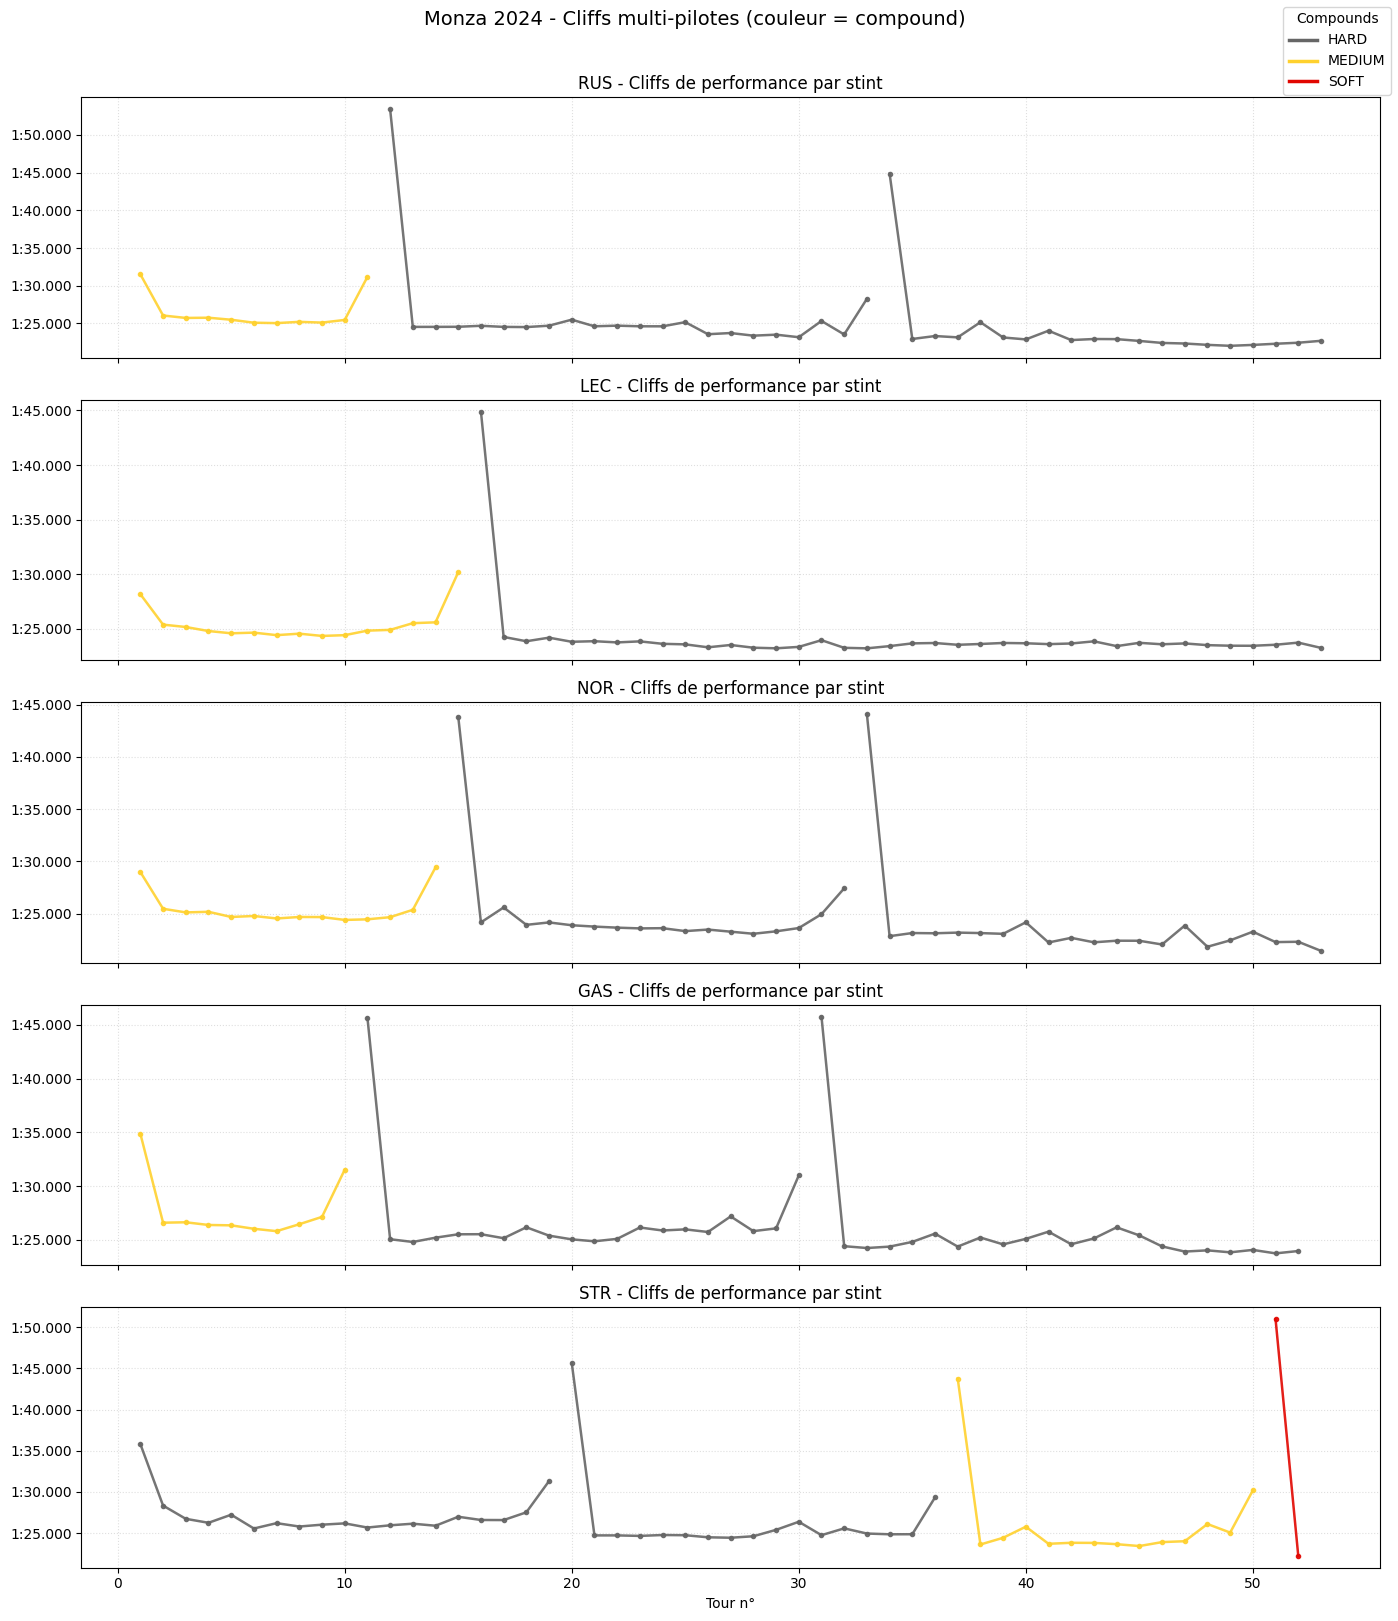

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated a

,TyreLife,DeltaToBestLapForStint
149,1.0,10.153500
150,2.0,1.930500
151,3.0,2.207502
152,4.0,1.993009
153,5.0,1.979848
...,...,...
238,9.0,2.241000
239,10.0,2.384000
240,11.0,4.506000
241,12.0,3.499500


In [12]:
# Visualisation cliffs (plusieurs pilotes) + compounds par stint
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# Recree l'instance pour garantir les nouvelles methodes de la classe
analyzer = F1Analyzer(2024, 'Monza', 'R')

# Choisis ici les pilotes a comparer
drivers = ['RUS', 'LEC', 'NOR', 'GAS', 'STR']

compound_colors = {
    'SOFT': '#E10600',
    'MEDIUM': '#FFD12E',
    'HARD': '#666666',
    'INTERMEDIATE': '#43B02A',
    'WET': '#0067AD',
    'UNKNOWN': '#888888'
}

def format_laptime(seconds, pos):
    if pd.isna(seconds):
        return ''
    minutes = int(seconds // 60)
    remainder = seconds % 60
    return f"{minutes}:{remainder:06.3f}"

fig, axes = plt.subplots(len(drivers), 1, figsize=(14, 3.2 * len(drivers)), sharex=True)
if len(drivers) == 1:
    axes = [axes]

stint_rows = []
used_compounds = set()

for ax, drv in zip(axes, drivers):
    drv_laps = analyzer.session.laps.pick_drivers([drv]).copy()
    drv_laps = drv_laps.dropna(subset=['LapNumber', 'LapTime']).sort_values('LapNumber')

    if drv_laps.empty:
        ax.set_title(f"{drv} - aucune donnee")
        ax.grid(visible=True, linestyle=':', alpha=0.4)
        continue

    drv_laps['LapTime_s'] = drv_laps['LapTime'].dt.total_seconds()

    # Trace par stint pour voir clairement les ruptures de performance
    for stint_id, stint_df in drv_laps.groupby('Stint', dropna=True):
        stint_df = stint_df.sort_values('LapNumber')
        if stint_df.empty:
            continue

        compound_series = stint_df['Compound'].dropna()
        compound = str(compound_series.mode().iloc[0]) if not compound_series.empty else 'UNKNOWN'
        color = compound_colors.get(compound, compound_colors['UNKNOWN'])
        used_compounds.add(compound)

        ax.plot(
            stint_df['LapNumber'],
            stint_df['LapTime_s'],
            color=color,
            marker='o',
            markersize=3,
            linewidth=1.8,
            alpha=0.9
        )

        start_lap = int(stint_df['LapNumber'].min())
        end_lap = int(stint_df['LapNumber'].max())

        stint_rows.append({
            'Driver': drv,
            'Stint': int(stint_id) if pd.notna(stint_id) else None,
            'StartLap': start_lap,
            'EndLap': end_lap,
            'Laps': end_lap - start_lap + 1,
            'Compound': compound
        })

    ax.set_title(f"{drv} - Cliffs de performance par stint")
    ax.yaxis.set_major_formatter(FuncFormatter(format_laptime))
    ax.grid(visible=True, linestyle=':', alpha=0.4)

axes[-1].set_xlabel('Tour n°')
fig.suptitle('Monza 2024 - Cliffs multi-pilotes (couleur = compound)', y=1.01, fontsize=14)

legend_compounds = sorted(used_compounds)
legend_handles = [
    Line2D([0], [0], color=compound_colors.get(c, compound_colors['UNKNOWN']), lw=2.5, label=c)
    for c in legend_compounds
]
if legend_handles:
    fig.legend(handles=legend_handles, title='Compounds', loc='upper right')

plt.tight_layout()
plt.show()

stint_compounds_df = pd.DataFrame(stint_rows).sort_values(['Driver', 'Stint']).reset_index(drop=True)

# Tableau detaille avec meilleur tour de chaque stint + delta au meilleur tour du stint
delta_frames = []
for drv in drivers:
    laps_corr = analyzer.get_clean_laps(drv)
    if laps_corr.empty:
        continue

    laps_corr = analyzer.add_drs_correction_to_laps(laps_corr)
    laps_corr = analyzer.add_dirty_air_correction_to_laps(laps_corr)
    laps_corr = analyzer.add_track_evolution_correction_to_laps(laps_corr)
    laps_corr = analyzer.add_temperature_correction_to_laps(laps_corr)
    laps_corr = analyzer.add_delta_to_best_lap_for_stint(
        laps_corr,
        corrected_col='CorrectedLapTime_Global',
        best_col='BestLapForStint',
        delta_col='DeltaToBestLapForStint'
    )

    keep_cols = [
        'Driver',
        'LapNumber',
        'Stint',
        'CorrectedLapTime_Global',
        'BestLapForStint',
        'DeltaToBestLapForStint',
        'IsBestLapForStint'
    ]
    delta_frames.append(laps_corr[keep_cols].dropna(subset=['Stint']))

stint_delta_df = pd.concat(delta_frames, ignore_index=True).sort_values(['Driver', 'Stint', 'LapNumber'])

tyre_delta_only_df = analyzer.extract_tyre_life_and_stint_delta(
    stint_delta_df,
    corrected_col='CorrectedLapTime_Global',
    delta_col='DeltaToBestLapForStint'
)

tyre_delta_only_df

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated a

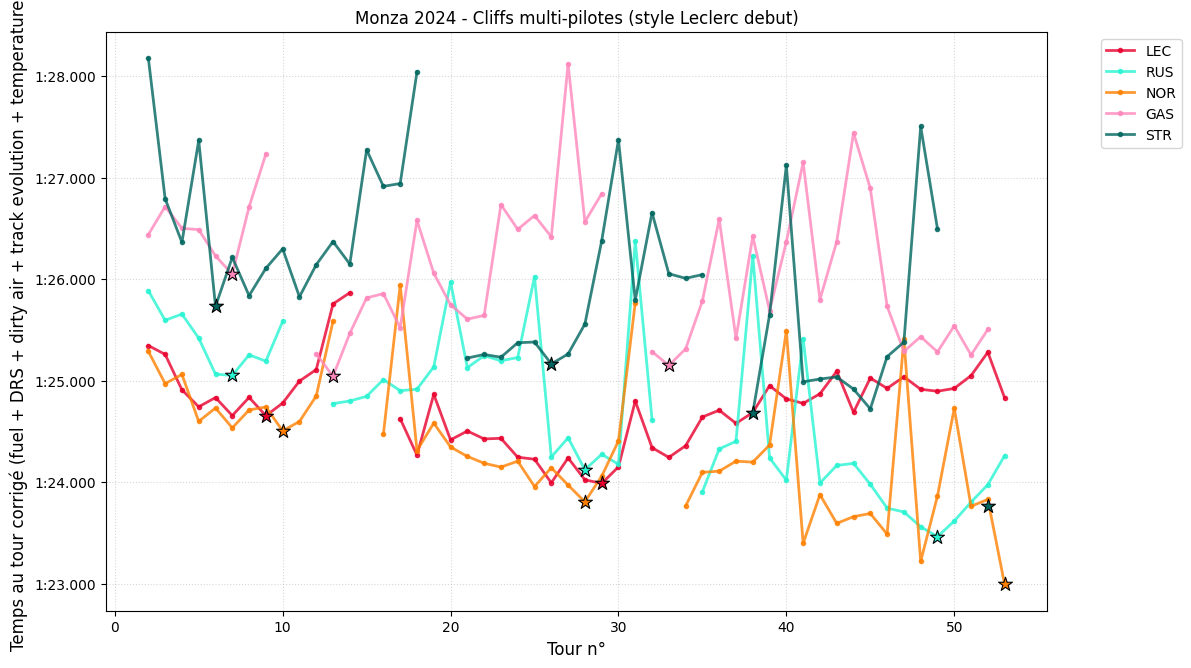

In [4]:
# Meme style que la visualisation du debut (mais pour plusieurs pilotes)
# Courbe unique, meme logique plot_drivers_pace

try:
    analyzer = analyzing_monza
except NameError:
    analyzer = F1Analyzer(2024, 'Monza', 'R')

multi_drivers = ['LEC', 'RUS', 'NOR', 'GAS', 'STR']

fig, ax = analyzer.plot_drivers_pace(
    analyzer.session,
    multi_drivers,
    very_clean=True,
    include_nan_laps=True,
    mode='global',
    highlight_best_lap_for_stint=True
)

plt.title('Monza 2024 - Cliffs multi-pilotes (style Leclerc debut)')
plt.show()

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Modele RANSAC polynomial degre 2 pour SAI stint 2:
intercept = 0.47654216
coef_x^1 = -0.05146890
coef_x^2 = 0.00248624
R2 (inliers) = 0.7171
Inliers: 29 | Outliers: 4


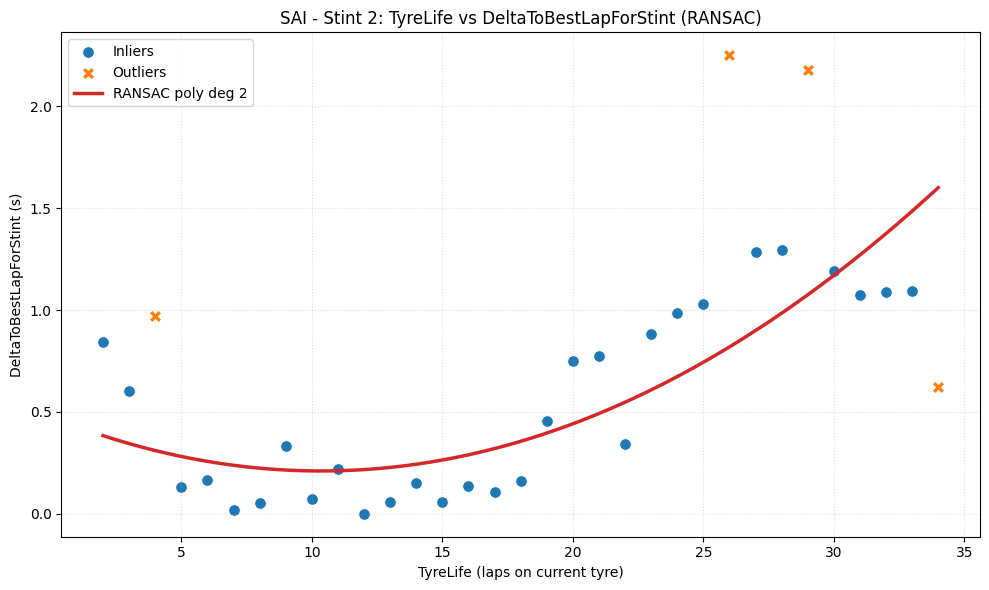

,LapNumber,Stint,TyreLife,DeltaToBestLapForStint
0,21.0,2.0,2.0,0.843000
1,22.0,2.0,3.0,0.603500
2,23.0,2.0,4.0,0.971000
3,24.0,2.0,5.0,0.131000
4,25.0,2.0,6.0,0.166500
5,26.0,2.0,7.0,0.019000
6,27.0,2.0,8.0,0.051000
7,28.0,2.0,9.0,0.334000
8,29.0,2.0,10.0,0.074500
9,30.0,2.0,11.0,0.219000


In [5]:
# Regression polynomiale robuste avec RANSAC sur SAI - stint 2
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.metrics import r2_score

analyzer = F1Analyzer(2024, 'Monza', 'R')

driver_code = 'SAI'
target_stint = 2
poly_degree = 2

laps_str = analyzer.get_clean_race_pace_laps(driver_code)
laps_str = analyzer.add_drs_correction_to_laps(laps_str)
laps_str = analyzer.add_dirty_air_correction_to_laps(laps_str)
laps_str = analyzer.add_track_evolution_correction_to_laps(laps_str)
laps_str = analyzer.add_temperature_correction_to_laps(laps_str)
laps_str = analyzer.add_delta_to_best_lap_for_stint(
    laps_str,
    corrected_col='CorrectedLapTime_Global',
    best_col='BestLapForStint',
    delta_col='DeltaToBestLapForStint'
 )
laps_str = analyzer.extract_tyre_life_and_stint_delta(
    laps_str,
    corrected_col='CorrectedLapTime_Global',
    delta_col='DeltaToBestLapForStint'
).join(laps_str[['LapNumber', 'Stint']], how='left')

stint_df = laps_str[(laps_str['Stint'] == target_stint)].dropna(subset=['TyreLife', 'DeltaToBestLapForStint']).copy()

if len(stint_df) < 5:
    raise ValueError('Pas assez de points pour une regression RANSAC polynomiale robuste.')

x = stint_df['TyreLife'].to_numpy(dtype=float)
y = stint_df['DeltaToBestLapForStint'].to_numpy(dtype=float)
X = x.reshape(-1, 1)

base_model = make_pipeline(
    PolynomialFeatures(degree=poly_degree, include_bias=False),
    LinearRegression()
 )
ransac_model = RANSACRegressor(
    estimator=base_model,
    min_samples=max(5, int(0.5 * len(X))),
    random_state=42
 )
ransac_model.fit(X, y)

inlier_mask = ransac_model.inlier_mask_
outlier_mask = ~inlier_mask

fitted_pipeline = ransac_model.estimator_
lin_reg = fitted_pipeline.named_steps['linearregression']
coefs = lin_reg.coef_
intercept = lin_reg.intercept_

print(f'Modele RANSAC polynomial degre {poly_degree} pour {driver_code} stint {target_stint}:')
print(f'intercept = {intercept:.8f}')
for i, coef in enumerate(coefs, start=1):
    print(f'coef_x^{i} = {coef:.8f}')

if inlier_mask.sum() >= 2:
    y_inlier_pred = ransac_model.predict(X[inlier_mask])
    r2_inliers = r2_score(y[inlier_mask], y_inlier_pred)
    print(f'R2 (inliers) = {r2_inliers:.4f}')
print(f'Inliers: {int(inlier_mask.sum())} | Outliers: {int(outlier_mask.sum())}')

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = ransac_model.predict(x_fit.reshape(-1, 1))

plot_df = stint_df.copy()
plot_df['Inlier'] = inlier_mask

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df[plot_df['Inlier']], x='TyreLife', y='DeltaToBestLapForStint', s=70, color='#1f77b4', label='Inliers')
if outlier_mask.any():
    sns.scatterplot(data=plot_df[~plot_df['Inlier']], x='TyreLife', y='DeltaToBestLapForStint', s=80, marker='X', color='#ff7f0e', label='Outliers')
sns.lineplot(x=x_fit, y=y_fit, color='#d62728', linewidth=2.5, label=f'RANSAC poly deg {poly_degree}')
plt.title(f'{driver_code} - Stint {target_stint}: TyreLife vs DeltaToBestLapForStint (RANSAC)')
plt.xlabel('TyreLife (laps on current tyre)')
plt.ylabel('DeltaToBestLapForStint (s)')
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

stint_df[['LapNumber', 'Stint', 'TyreLife', 'DeltaToBestLapForStint']].sort_values('TyreLife').reset_index(drop=True)

In [6]:
# Bloc 1 - Partie B: Profil global de degradation par compound (Monza 2024)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, RANSACRegressor

# 0) Base de donnees: tous les pilotes, tours propres
try:
    analyzer = analyzing_monza
except NameError:
    analyzer = F1Analyzer(2024, 'Monza', 'R')

laps_all = analyzer.session.laps.copy()
laps_all = laps_all.dropna(subset=['Driver', 'LapNumber', 'Stint', 'Compound', 'LapTime'])

# 1) Appliquer les corrections globales
laps_all = analyzer.add_drs_correction_to_laps(laps_all)
laps_all = analyzer.add_dirty_air_correction_to_laps(laps_all)
laps_all = analyzer.add_track_evolution_correction_to_laps(laps_all)
laps_all = analyzer.add_temperature_correction_to_laps(laps_all)
laps_all = analyzer.add_delta_to_best_lap_for_stint(
    laps_all,
    corrected_col='CorrectedLapTime_Global',
    best_col='BestLapForStint',
    delta_col='DeltaToBestLapForStint'
 )

# TyreLife propre (fallback si manquant)
if 'TyreLife' not in laps_all.columns:
    laps_all['TyreLife'] = np.nan
laps_all['TyreLife'] = pd.to_numeric(laps_all['TyreLife'], errors='coerce')
missing_tl = laps_all['TyreLife'].isna()
if missing_tl.any():
    laps_all.loc[missing_tl, 'TyreLife'] = (
        laps_all.loc[missing_tl]
        .groupby(['Driver', 'Stint'], dropna=False)
        .cumcount() + 1
    )

# 2) Construction du dictionnaire des profils globaux
compounds = ['SOFT', 'MEDIUM', 'HARD']
global_profiles = {}
poly_degree = 2
base_model = make_pipeline(
    PolynomialFeatures(degree=poly_degree, include_bias=False),
    LinearRegression()
 )

for compound in compounds:
    all_laps_compound = laps_all[laps_all['Compound'] == compound].dropna(
        subset=['TyreLife', 'DeltaToBestLapForStint']
    )

    if len(all_laps_compound) < 10:
        print(f"{compound}: pas assez de donnees ({len(all_laps_compound)} points)")
        continue

    X_global = all_laps_compound['TyreLife'].to_numpy(dtype=float).reshape(-1, 1)
    y_global = all_laps_compound['DeltaToBestLapForStint'].to_numpy(dtype=float)

    ransac_global = RANSACRegressor(
        estimator=base_model,
        min_samples=max(10, int(0.5 * len(X_global))),
        random_state=42
    )
    ransac_global.fit(X_global, y_global)

    model_pipeline = ransac_global.estimator_
    lin_reg = model_pipeline.named_steps['linearregression']
    coefs = lin_reg.coef_

    # y = b*x + a*x^2 + c car include_bias=False
    global_profiles[compound] = {
        'a': float(coefs[1]) if len(coefs) > 1 else 0.0,
        'b': float(coefs[0]) if len(coefs) > 0 else 0.0,
        'c': float(lin_reg.intercept_),
        'n_points': int(len(all_laps_compound)),
        'n_inliers': int(ransac_global.inlier_mask_.sum())
    }

global_profiles

SOFT: pas assez de donnees (2 points)


{'MEDIUM': {'a': 0.026013945651324078,
  'b': -0.5019122041872225,
  'c': 3.940434232156804,
  'n_points': 274,
  'n_inliers': 116},
 'HARD': {'a': 0.00580727547650031,
  'b': -0.22113717940448854,
  'c': 3.6302384818986178,
  'n_points': 732,
  'n_inliers': 234}}

In [19]:
# Bloc 1 - Partie C: Boucle sur toutes les courses en cache (meme logique que Monza)
import os
import re
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, RANSACRegressor

CACHE_ROOT = '../cache_strategy'
TARGET_COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']
MIN_POINTS = 10
POLY_DEGREE = 2

try:
    circuit_stats
except NameError:
    circuit_stats = {
        'Bahrain Grand Prix': {'abrasivity': 5, 'lateral_energy': 3, 'type': 'Traction/Braking'},
        'Saudi Arabian Grand Prix': {'abrasivity': 2, 'lateral_energy': 4, 'type': 'High-Speed Street'},
        'Australian Grand Prix': {'abrasivity': 3, 'lateral_energy': 3, 'type': 'Semi-Permanent'},
        'Japanese Grand Prix': {'abrasivity': 5, 'lateral_energy': 5, 'type': 'High-Energy Technical'},
        'Chinese Grand Prix': {'abrasivity': 3, 'lateral_energy': 4, 'type': 'Technical/Front-Limited'},
        'Miami Grand Prix': {'abrasivity': 3, 'lateral_energy': 3, 'type': 'Street'},
        'Emilia Romagna Grand Prix': {'abrasivity': 3, 'lateral_energy': 3, 'type': 'Old-School Technical'},
        'Monaco Grand Prix': {'abrasivity': 1, 'lateral_energy': 1, 'type': 'Low-Speed Street'},
        'Canadian Grand Prix': {'abrasivity': 2, 'lateral_energy': 2, 'type': 'Stop-and-Go'},
        'Spanish Grand Prix': {'abrasivity': 4, 'lateral_energy': 5, 'type': 'Aero-Reference'},
        'Austrian Grand Prix': {'abrasivity': 2, 'lateral_energy': 3, 'type': 'High-Speed/Short'},
        'British Grand Prix': {'abrasivity': 3, 'lateral_energy': 5, 'type': 'High-Energy Aero'},
        'Hungarian Grand Prix': {'abrasivity': 2, 'lateral_energy': 3, 'type': 'Twisty/Low-Speed'},
        'Belgian Grand Prix': {'abrasivity': 4, 'lateral_energy': 5, 'type': 'Power/High-Energy'},
        'Dutch Grand Prix': {'abrasivity': 3, 'lateral_energy': 5, 'type': 'Banking/High-Energy'},
        'Italian Grand Prix': {'abrasivity': 2, 'lateral_energy': 3, 'type': 'Ultra-High Speed'},
        'Azerbaijan Grand Prix': {'abrasivity': 2, 'lateral_energy': 2, 'type': 'Street/Long-Straight'},
        'Singapore Grand Prix': {'abrasivity': 4, 'lateral_energy': 2, 'type': 'Street/Bumpy'},
        'United States Grand Prix': {'abrasivity': 4, 'lateral_energy': 4, 'type': 'Mix/Bumpy'},
        'Mexico City Grand Prix': {'abrasivity': 2, 'lateral_energy': 2, 'type': 'Altitude/Low-Downforce'},
        'Sao Paulo Grand Prix': {'abrasivity': 3, 'lateral_energy': 3, 'type': 'Technical/Short'},
        'Las Vegas Grand Prix': {'abrasivity': 2, 'lateral_energy': 2, 'type': 'Street/Cold'},
        'Qatar Grand Prix': {'abrasivity': 4, 'lateral_energy': 5, 'type': 'High-Speed/Flat'},
        'Abu Dhabi Grand Prix': {'abrasivity': 3, 'lateral_energy': 3, 'type': 'Technical/Standard'}
    }

def discover_cached_races(cache_root):
    races = []
    if not os.path.isdir(cache_root):
        return races

    for year_name in sorted(os.listdir(cache_root)):
        year_path = os.path.join(cache_root, year_name)
        if not (os.path.isdir(year_path) and year_name.isdigit()):
            continue

        for event_dir in sorted(os.listdir(year_path)):
            event_path = os.path.join(year_path, event_dir)
            if not os.path.isdir(event_path):
                continue

            match = re.match(r'\d{4}-\d{2}-\d{2}_(.+)$', event_dir)
            if match is None:
                continue

            event_name = match.group(1).replace('_', ' ')
            if any(session_dir.endswith('_Race') for session_dir in os.listdir(event_path)):
                races.append((int(year_name), event_name))

    return races

def compute_global_profiles_for_analyzer(analyzer, min_points=10, poly_degree=2):
    laps_all = analyzer.session.laps.copy()
    laps_all = laps_all.dropna(subset=['Driver', 'LapNumber', 'Stint', 'Compound', 'LapTime'])

    laps_all = analyzer.add_drs_correction_to_laps(laps_all)
    laps_all = analyzer.add_dirty_air_correction_to_laps(laps_all)
    laps_all = analyzer.add_track_evolution_correction_to_laps(laps_all)
    laps_all = analyzer.add_temperature_correction_to_laps(laps_all)
    laps_all = analyzer.add_delta_to_best_lap_for_stint(
        laps_all,
        corrected_col='CorrectedLapTime_Global',
        best_col='BestLapForStint',
        delta_col='DeltaToBestLapForStint'
    )

    if 'TyreLife' not in laps_all.columns:
        laps_all['TyreLife'] = np.nan
    laps_all['TyreLife'] = pd.to_numeric(laps_all['TyreLife'], errors='coerce')
    missing_tl = laps_all['TyreLife'].isna()
    if missing_tl.any():
        laps_all.loc[missing_tl, 'TyreLife'] = (
            laps_all.loc[missing_tl]
            .groupby(['Driver', 'Stint'], dropna=False)
            .cumcount() + 1
        )

    base_model = make_pipeline(
        PolynomialFeatures(degree=poly_degree, include_bias=False),
        LinearRegression()
    )

    profiles = {}
    for compound in TARGET_COMPOUNDS:
        df_c = laps_all[laps_all['Compound'] == compound].dropna(subset=['TyreLife', 'DeltaToBestLapForStint'])
        if len(df_c) < min_points:
            continue

        X = df_c['TyreLife'].to_numpy(dtype=float).reshape(-1, 1)
        y = df_c['DeltaToBestLapForStint'].to_numpy(dtype=float)

        ransac = RANSACRegressor(
            estimator=base_model,
            min_samples=max(min_points, int(0.5 * len(X))),
            random_state=42
        )
        ransac.fit(X, y)

        lin_reg = ransac.estimator_.named_steps['linearregression']
        coefs = lin_reg.coef_

        profiles[compound] = {
            'a': float(coefs[1]) if len(coefs) > 1 else 0.0,
            'b': float(coefs[0]) if len(coefs) > 0 else 0.0,
            'c': float(lin_reg.intercept_),
            'n_points': int(len(df_c)),
            'n_inliers': int(ransac.inlier_mask_.sum())
        }

    track_temp_values = []
    air_temp_values = []
    if hasattr(laps_all, 'iterlaps'):
        for _, lap in laps_all.iterlaps():
            try:
                weather = lap.get_weather_data()
                if weather is not None:
                    if 'TrackTemp' in weather.index and pd.notna(weather['TrackTemp']):
                        track_temp_values.append(float(weather['TrackTemp']))
                    if 'AirTemp' in weather.index and pd.notna(weather['AirTemp']):
                        air_temp_values.append(float(weather['AirTemp']))
            except Exception:
                pass

    session_stats = {
        'AverageTrackTemp_C': float(np.mean(track_temp_values)) if track_temp_values else np.nan,
        'AverageAirTemp_C': float(np.mean(air_temp_values)) if air_temp_values else np.nan,
        'N_Treated_Laps': int(len(laps_all))
    }

    return profiles, session_stats

cached_races = discover_cached_races(CACHE_ROOT)
print(f'Courses detectees dans le cache: {len(cached_races)}')

all_global_profiles = {}
rows = []

for year, event_name in cached_races:
    try:
        analyzer_loop = F1Analyzer(year, event_name, 'R')
        profiles, session_stats = compute_global_profiles_for_analyzer(
            analyzer_loop,
            min_points=MIN_POINTS,
            poly_degree=POLY_DEGREE
        )
        all_global_profiles[(year, event_name)] = profiles

        circuit_key = f'{event_name} Grand Prix'
        circuit_info = circuit_stats.get(circuit_key, {})

        for compound, vals in profiles.items():
            rows.append({
                'Year': year,
                'Event': event_name,
                'Compound': compound,
                'a': vals['a'],
                'b': vals['b'],
                'c': vals['c'],
                'n_points': vals['n_points'],
                'n_inliers': vals['n_inliers'],
                'abrasivity': circuit_info.get('abrasivity', np.nan),
                'lateral_energy': circuit_info.get('lateral_energy', np.nan),
                'circuit_type': circuit_info.get('type', np.nan),
                'AverageTrackTemp_C': session_stats['AverageTrackTemp_C'],
                'AverageAirTemp_C': session_stats['AverageAirTemp_C'],
                'N_Treated_Laps': session_stats['N_Treated_Laps']
            })

        print(f"OK - {year} {event_name}: {list(profiles.keys()) if profiles else 'aucun compound valide'}")
    except Exception as e:
        print(f"ECHEC - {year} {event_name}: {e}")

if rows:
    profiles_df = pd.DataFrame(rows).sort_values(['Year', 'Event', 'Compound']).reset_index(drop=True)
else:
    profiles_df = pd.DataFrame(columns=['Year', 'Event', 'Compound', 'a', 'b', 'c', 'n_points', 'n_inliers', 'abrasivity', 'lateral_energy', 'circuit_type', 'AverageTrackTemp_C', 'AverageAirTemp_C', 'N_Treated_Laps'])

profiles_df

Courses detectees dans le cache: 9
OK - 2024 Bahrain Grand Prix: ['SOFT', 'HARD']
OK - 2024 Japanese Grand Prix: ['SOFT', 'MEDIUM', 'HARD']
OK - 2024 Monaco Grand Prix: ['SOFT', 'MEDIUM', 'HARD']


core        WARNING 	Driver 1 completed the race distance 00:00.015000 before the recorded end of the session.


OK - 2024 Spanish Grand Prix: ['SOFT', 'MEDIUM', 'HARD']


core        WARNING 	Fixed incorrect tyre stint information for driver '14'
core        WARNING 	Fixed incorrect tyre stint information for driver '3'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'


OK - 2024 British Grand Prix: ['SOFT', 'MEDIUM', 'HARD']


core        WARNING 	Fixed incorrect tyre stint information for driver '22'


OK - 2024 Belgian Grand Prix: ['SOFT', 'MEDIUM', 'HARD']


events      WARNING 	Correcting user input 'United States Grand Prix' to 'United States Grand Prix'


OK - 2024 Italian Grand Prix: ['MEDIUM', 'HARD']
OK - 2024 United States Grand Prix: ['MEDIUM', 'HARD']
OK - 2024 Abu Dhabi Grand Prix: ['SOFT', 'MEDIUM', 'HARD']


,Year,Event,Compound,a,b,c,n_points,n_inliers,abrasivity,lateral_energy,circuit_type,AverageTrackTemp_C,AverageAirTemp_C,N_Treated_Laps
0,2024,Abu Dhabi Grand Prix,HARD,0.006886,-0.311550,4.912756,689,241,NaN,NaN,NaN,30.712875,26.437173,1033
1,2024,Abu Dhabi Grand Prix,MEDIUM,0.046071,-1.462675,11.693450,317,78,NaN,NaN,NaN,30.712875,26.437173,1033
2,2024,Abu Dhabi Grand Prix,SOFT,0.010753,-0.172791,2.535330,27,20,NaN,NaN,NaN,30.712875,26.437173,1033
3,2024,Bahrain Grand Prix,HARD,0.027860,-0.748682,7.208598,790,298,NaN,NaN,NaN,22.811979,18.003638,1127
4,2024,Bahrain Grand Prix,SOFT,0.028499,-0.548514,4.400674,337,140,NaN,NaN,NaN,22.811979,18.003638,1127
5,2024,Belgian Grand Prix,HARD,0.004702,-0.149034,3.161569,412,180,NaN,NaN,NaN,43.015119,21.591548,840
6,2024,Belgian Grand Prix,MEDIUM,0.001025,-0.057860,2.823704,366,147,NaN,NaN,NaN,43.015119,21.591548,840
7,2024,Belgian Grand Prix,SOFT,-0.005027,0.118039,2.230776,62,27,NaN,NaN,NaN,43.015119,21.591548,840
8,2024,British Grand Prix,HARD,0.029769,-0.430855,2.034900,44,28,NaN,NaN,NaN,23.965208,15.652604,960
9,2024,British Grand Prix,MEDIUM,0.038995,-0.826707,5.527144,508,207,NaN,NaN,NaN,23.965208,15.652604,960


In [ ]:
circuit_stats = {
    "Bahrain Grand Prix": {"abrasivity": 5, "lateral_energy": 3, "type": "Traction/Braking"},
    "Saudi Arabian Grand Prix": {"abrasivity": 2, "lateral_energy": 4, "type": "High-Speed Street"},
    "Australian Grand Prix": {"abrasivity": 3, "lateral_energy": 3, "type": "Semi-Permanent"},
    "Japanese Grand Prix": {"abrasivity": 5, "lateral_energy": 5, "type": "High-Energy Technical"},
    "Chinese Grand Prix": {"abrasivity": 3, "lateral_energy": 4, "type": "Technical/Front-Limited"},
    "Miami Grand Prix": {"abrasivity": 3, "lateral_energy": 3, "type": "Street"},
    "Emilia Romagna Grand Prix": {"abrasivity": 3, "lateral_energy": 3, "type": "Old-School Technical"},
    "Monaco Grand Prix": {"abrasivity": 1, "lateral_energy": 1, "type": "Low-Speed Street"},
    "Canadian Grand Prix": {"abrasivity": 2, "lateral_energy": 2, "type": "Stop-and-Go"},
    "Spanish Grand Prix": {"abrasivity": 4, "lateral_energy": 5, "type": "Aero-Reference"},
    "Austrian Grand Prix": {"abrasivity": 2, "lateral_energy": 3, "type": "High-Speed/Short"},
    "British Grand Prix": {"abrasivity": 3, "lateral_energy": 5, "type": "High-Energy Aero"},
    "Hungarian Grand Prix": {"abrasivity": 2, "lateral_energy": 3, "type": "Twisty/Low-Speed"},
    "Belgian Grand Prix": {"abrasivity": 4, "lateral_energy": 5, "type": "Power/High-Energy"},
    "Dutch Grand Prix": {"abrasivity": 3, "lateral_energy": 5, "type": "Banking/High-Energy"},
    "Italian Grand Prix": {"abrasivity": 2, "lateral_energy": 3, "type": "Ultra-High Speed"},
    "Azerbaijan Grand Prix": {"abrasivity": 2, "lateral_energy": 2, "type": "Street/Long-Straight"},
    "Singapore Grand Prix": {"abrasivity": 4, "lateral_energy": 2, "type": "Street/Bumpy"},
    "United States Grand Prix": {"abrasivity": 4, "lateral_energy": 4, "type": "Mix/Bumpy"},
    "Mexico City Grand Prix": {"abrasivity": 2, "lateral_energy": 2, "type": "Altitude/Low-Downforce"},
    "São Paulo Grand Prix": {"abrasivity": 3, "lateral_energy": 3, "type": "Technical/Short"},
    "Las Vegas Grand Prix": {"abrasivity": 2, "lateral_energy": 2, "type": "Street/Cold"},
    "Qatar Grand Prix": {"abrasivity": 4, "lateral_energy": 5, "type": "High-Speed/Flat"},
    "Abu Dhabi Grand Prix": {"abrasivity": 3, "lateral_energy": 3, "type": "Technical/Standard"}
}


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       24 non-null     int64  
 1   Event      24 non-null     object 
 2   Compound   24 non-null     object 
 3   a          24 non-null     float64
 4   b          24 non-null     float64
 5   c          24 non-null     float64
 6   n_points   24 non-null     int64  
 7   n_inliers  24 non-null     int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 1.6+ KB


In [20]:
profiles_df.to_csv('global_tyre_degradation_profiles.csv', index=False)